# CS:4420 Course Project: IMDB Text Classification with LSTM

This project builds a binary sentiment classifier for IMDB movie reviews using PyTorch. The goal is to load and explore the IMDB dataset, create a balanced validation split, preprocess the text, train an LSTM-based classifier, and evaluate the final model using accuracy, precision, recall, F1 score, and AUC.

In [1]:
import os
import re
import string
import random
import tarfile

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [7]:
tar_path = "aclImdb_v1-1.tar.gz"
extract_path = "."

if not os.path.exists("aclImdb"):
    with tarfile.open(tar_path, "r:gz") as tar:
        tar.extractall(path=extract_path)
    print("Dataset extracted.")
else:
    print("Dataset already extracted.")

Dataset extracted.


In [10]:
print(os.listdir("aclImdb"))
print(os.listdir("aclImdb/train"))
print(os.listdir("aclImdb/test"))

['imdb.vocab', 'imdbEr.txt', 'README', 'test', 'train']
['labeledBow.feat', 'neg', 'pos', 'unsup', 'unsupBow.feat', 'urls_neg.txt', 'urls_pos.txt', 'urls_unsup.txt']
['labeledBow.feat', 'neg', 'pos', 'urls_neg.txt', 'urls_pos.txt']


## Task 1: Understanding the Data

In this section, I load the IMDB train and test review files and compute basic review-length statistics. These statistics help determine how long input sequences should be when training the LSTM model.

In [9]:
def load_imdb_split(split):
    texts = []
    labels = []

    for label_name, label_value in [("neg", 0), ("pos", 1)]:
        folder_path = os.path.join("aclImdb", split, label_name)

        for filename in os.listdir(folder_path):
            if filename.endswith(".txt"):
                file_path = os.path.join(folder_path, filename)

                with open(file_path, "r", encoding="utf-8") as file:
                    text = file.read()

                texts.append(text)
                labels.append(label_value)

    return texts, labels


train_texts, train_labels = load_imdb_split("train")
test_texts, test_labels = load_imdb_split("test")

print("Number of training reviews:", len(train_texts))
print("Number of test reviews:", len(test_texts))
print("First training label:", train_labels[0])
print("First training review preview:")
print(train_texts[0][:500])

Number of training reviews: 25000
Number of test reviews: 25000
First training label: 0
First training review preview:
Story of a man who has unnatural feelings for a pig. Starts out with a opening scene that is a terrific example of absurd comedy. A formal orchestra audience is turned into an insane, violent mob by the crazy chantings of it's singers. Unfortunately it stays absurd the WHOLE time with no general narrative eventually making it just too off putting. Even those from the era should be turned off. The cryptic dialogue would make Shakespeare seem easy to a third grader. On a technical level it's bette


In [11]:
def review_length_stats(texts):
    lengths = []

    for text in texts:
        words = text.split()
        lengths.append(len(words))

    avg_length = np.mean(lengths)
    max_length = np.max(lengths)
    min_length = np.min(lengths)

    return avg_length, max_length, min_length, lengths


train_avg, train_max, train_min, train_lengths = review_length_stats(train_texts)
test_avg, test_max, test_min, test_lengths = review_length_stats(test_texts)

print("Training Set Review Lengths")
print("Average length:", train_avg)
print("Maximum length:", train_max)
print("Minimum length:", train_min)

print("\nTest Set Review Lengths")
print("Average length:", test_avg)
print("Maximum length:", test_max)
print("Minimum length:", test_min)

Training Set Review Lengths
Average length: 233.7872
Maximum length: 2470
Minimum length: 10

Test Set Review Lengths
Average length: 228.52668
Maximum length: 2278
Minimum length: 4


### Task 1 Analysis

The training set contains 25,000 reviews and the test set contains 25,000 reviews. In the training set, the average review length is about 233.79 words, with a maximum length of 2470 words and a minimum length of 10 words. In the test set, the average review length is about 228.53 words, with a maximum length of 2278 words and a minimum length of 4 words.

These results show that most reviews are a few hundred words long, but there are also some very long reviews. This matters for an LSTM because every review must be converted into a fixed-length input sequence before training. If the sequence length is too short, useful information from longer reviews may be cut off. If it is too long, training becomes slower and many shorter reviews will need a lot of padding. Based on these statistics, a reasonable sequence length should capture most typical reviews while avoiding the cost of using the maximum review length. For this project, I will use a fixed sequence length later during preprocessing so that long reviews are truncated and short reviews are padded.

## Task 2: Creating a Balanced Validation Split

In this section, I create a validation set from the original training data. The validation set contains 3000 total reviews, with 1500 negative reviews and 1500 positive reviews. After creating the validation set, I report the class distribution for the new training set, validation set, and test set.

In [12]:
# Set a random seed so the split is reproducible
random.seed(42)

# Get the indices of negative and positive training reviews
negative_indices = [i for i, label in enumerate(train_labels) if label == 0]
positive_indices = [i for i, label in enumerate(train_labels) if label == 1]

# Randomly select 1500 negative and 1500 positive reviews for validation
validation_negative_indices = random.sample(negative_indices, 1500)
validation_positive_indices = random.sample(positive_indices, 1500)

# Combine validation indices into one set for easy lookup
validation_indices = set(validation_negative_indices + validation_positive_indices)

# Create the new validation set
val_texts = [train_texts[i] for i in validation_indices]
val_labels = [train_labels[i] for i in validation_indices]

# Create the new training set by excluding validation samples
new_train_texts = [text for i, text in enumerate(train_texts) if i not in validation_indices]
new_train_labels = [label for i, label in enumerate(train_labels) if i not in validation_indices]

print("New training set size:", len(new_train_texts))
print("Validation set size:", len(val_texts))
print("Test set size:", len(test_texts))

New training set size: 22000
Validation set size: 3000
Test set size: 25000


In [13]:
def label_distribution(labels):
    negative_count = labels.count(0)
    positive_count = labels.count(1)
    total_count = len(labels)

    return negative_count, positive_count, total_count


train_neg, train_pos, train_total = label_distribution(new_train_labels)
val_neg, val_pos, val_total = label_distribution(val_labels)
test_neg, test_pos, test_total = label_distribution(test_labels)

print("New Training Set Distribution")
print("Negative:", train_neg)
print("Positive:", train_pos)
print("Total:", train_total)

print("\nValidation Set Distribution")
print("Negative:", val_neg)
print("Positive:", val_pos)
print("Total:", val_total)

print("\nTest Set Distribution")
print("Negative:", test_neg)
print("Positive:", test_pos)
print("Total:", test_total)

New Training Set Distribution
Negative: 11000
Positive: 11000
Total: 22000

Validation Set Distribution
Negative: 1500
Positive: 1500
Total: 3000

Test Set Distribution
Negative: 12500
Positive: 12500
Total: 25000


### Task 2 Analysis

The original IMDB training set was split into a new training set and a balanced validation set. The validation set contains 3000 total reviews, with 1500 negative reviews and 1500 positive reviews. This satisfies the requirement that the validation set have an equal number of positive and negative samples.

After the split, the new training set contains 22,000 reviews, with 11,000 negative reviews and 11,000 positive reviews. The test set contains 25,000 reviews, with 12,500 negative reviews and 12,500 positive reviews. Since all three sets are balanced, accuracy will be a useful metric later, because the model cannot get a high score just by guessing the majority class.

## Task 3: Data Preprocessing

In this section, I preprocess the movie reviews before converting them into numerical input for the LSTM model. The preprocessing steps include lowercasing the text, removing punctuation, tokenizing the text, removing stop words, and applying stemming.

In [14]:
import nltk

nltk.download("stopwords")

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\gabem\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


In [15]:
stop_words = set(stopwords.words("english"))
stemmer = PorterStemmer()

def preprocess_text(text):
    # Convert text to lowercase
    text = text.lower()

    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Tokenize the text by splitting on whitespace
    tokens = text.split()

    # Remove stop words and apply stemming
    processed_tokens = []

    for token in tokens:
        if token not in stop_words:
            stemmed_token = stemmer.stem(token)
            processed_tokens.append(stemmed_token)

    return processed_tokens

In [16]:
example_review = new_train_texts[0]

print("Original review:")
print(example_review[:1000])

print("\nPreprocessed review:")
print(preprocess_text(example_review)[:100])

Original review:
Story of a man who has unnatural feelings for a pig. Starts out with a opening scene that is a terrific example of absurd comedy. A formal orchestra audience is turned into an insane, violent mob by the crazy chantings of it's singers. Unfortunately it stays absurd the WHOLE time with no general narrative eventually making it just too off putting. Even those from the era should be turned off. The cryptic dialogue would make Shakespeare seem easy to a third grader. On a technical level it's better than you might think with some good cinematography by future great Vilmos Zsigmond. Future stars Sally Kirkland and Frederic Forrest can be seen briefly.

Preprocessed review:
['stori', 'man', 'unnatur', 'feel', 'pig', 'start', 'open', 'scene', 'terrif', 'exampl', 'absurd', 'comedi', 'formal', 'orchestra', 'audienc', 'turn', 'insan', 'violent', 'mob', 'crazi', 'chant', 'singer', 'unfortun', 'stay', 'absurd', 'whole', 'time', 'gener', 'narr', 'eventu', 'make', 'put', 'even', 'e

### Task 3 Analysis

The preprocessing function converts each review to lowercase, removes punctuation, splits the text into tokens, removes common English stop words, and applies Porter stemming. This reduces noise in the text and helps the model focus on more meaningful word patterns. For example, words such as "story" and "feelings" are converted to stemmed forms like "stori" and "feel." This preprocessing step prepares the raw movie reviews for vocabulary creation and numerical encoding before they are passed into the LSTM model.

In [20]:
processed_train_texts = [preprocess_text(text) for text in new_train_texts]
processed_val_texts = [preprocess_text(text) for text in val_texts]
processed_test_texts = [preprocess_text(text) for text in test_texts]

print("Processed training reviews:", len(processed_train_texts))
print("Processed validation reviews:", len(processed_val_texts))
print("Processed test reviews:", len(processed_test_texts))

print("\nExample processed training review:")
print(processed_train_texts[0][:50])

Processed training reviews: 22000
Processed validation reviews: 3000
Processed test reviews: 25000

Example processed training review:
['stori', 'man', 'unnatur', 'feel', 'pig', 'start', 'open', 'scene', 'terrif', 'exampl', 'absurd', 'comedi', 'formal', 'orchestra', 'audienc', 'turn', 'insan', 'violent', 'mob', 'crazi', 'chant', 'singer', 'unfortun', 'stay', 'absurd', 'whole', 'time', 'gener', 'narr', 'eventu', 'make', 'put', 'even', 'era', 'turn', 'cryptic', 'dialogu', 'would', 'make', 'shakespear', 'seem', 'easi', 'third', 'grader', 'technic', 'level', 'better', 'might', 'think', 'good']


In [21]:
from collections import Counter

MAX_VOCAB_SIZE = 20000

def build_vocab(processed_texts, max_vocab_size):
    word_counts = Counter()

    for tokens in processed_texts:
        word_counts.update(tokens)

    most_common_words = word_counts.most_common(max_vocab_size - 2)

    vocab = {
        "<PAD>": 0,
        "<UNK>": 1
    }

    for index, (word, count) in enumerate(most_common_words, start=2):
        vocab[word] = index

    return vocab, word_counts


vocab, word_counts = build_vocab(processed_train_texts, MAX_VOCAB_SIZE)

print("Vocabulary size:", len(vocab))
print("Most common words:")
print(word_counts.most_common(20))

Vocabulary size: 20000
Most common words:
[('movi', 44499), ('film', 41511), ('one', 23735), ('like', 19559), ('time', 13615), ('good', 13081), ('make', 12641), ('get', 12393), ('see', 12267), ('charact', 12260), ('watch', 12177), ('stori', 11354), ('even', 11252), ('would', 10624), ('realli', 10308), ('scene', 9309), ('well', 8768), ('show', 8506), ('look', 8488), ('much', 8484)]


In [22]:
stop_words = set(stopwords.words("english"))
stemmer = PorterStemmer()

def preprocess_text(text):
    # Convert text to lowercase
    text = text.lower()

    # Remove HTML line break tags that appear often in IMDB reviews
    text = text.replace("<br />", " ")

    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Tokenize the text by splitting on whitespace
    tokens = text.split()

    # Remove stop words, remove leftover "br", and apply stemming
    processed_tokens = []

    for token in tokens:
        if token not in stop_words and token != "br":
            stemmed_token = stemmer.stem(token)
            processed_tokens.append(stemmed_token)

    return processed_tokens

In [23]:
MAX_SEQUENCE_LENGTH = 250

def encode_and_pad(tokens, vocab, max_length):
    # Convert each token into its vocabulary index
    encoded = []

    for token in tokens:
        if token in vocab:
            encoded.append(vocab[token])
        else:
            encoded.append(vocab["<UNK>"])

    # If the review is longer than max_length, cut it off
    if len(encoded) > max_length:
        encoded = encoded[:max_length]

    # If the review is shorter than max_length, pad it with 0s
    if len(encoded) < max_length:
        padding_needed = max_length - len(encoded)
        encoded = encoded + [vocab["<PAD>"]] * padding_needed

    return encoded


X_train = [encode_and_pad(tokens, vocab, MAX_SEQUENCE_LENGTH) for tokens in processed_train_texts]
X_val = [encode_and_pad(tokens, vocab, MAX_SEQUENCE_LENGTH) for tokens in processed_val_texts]
X_test = [encode_and_pad(tokens, vocab, MAX_SEQUENCE_LENGTH) for tokens in processed_test_texts]

y_train = new_train_labels
y_val = val_labels
y_test = test_labels

print("Encoded training samples:", len(X_train))
print("Encoded validation samples:", len(X_val))
print("Encoded test samples:", len(X_test))
print("Length of one encoded review:", len(X_train[0]))
print("First 30 encoded values:")
print(X_train[0][:30])

Encoded training samples: 22000
Encoded validation samples: 3000
Encoded test samples: 25000
Length of one encoded review: 250
First 30 encoded values:
[13, 59, 4981, 63, 2809, 87, 257, 17, 1137, 350, 1254, 113, 7461, 5413, 182, 99, 1485, 985, 2528, 819, 6284, 1503, 344, 448, 1254, 149, 6, 268, 1138, 708]


## Task 4: Implementing an LSTM Text Classifier

In this section, I convert the encoded IMDB reviews into PyTorch datasets and data loaders, then define and train an LSTM-based text classifier. The model uses an embedding layer to convert word indices into dense vectors, an LSTM layer to process the sequence of words, and a fully connected layer to classify each review as negative or positive.

In [24]:
class IMDBDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = torch.tensor(texts, dtype=torch.long)
        self.labels = torch.tensor(labels, dtype=torch.float32)

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, index):
        return self.texts[index], self.labels[index]


BATCH_SIZE = 64

train_dataset = IMDBDataset(X_train, y_train)
val_dataset = IMDBDataset(X_val, y_val)
test_dataset = IMDBDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

sample_text_batch, sample_label_batch = next(iter(train_loader))

print("Sample text batch shape:", sample_text_batch.shape)
print("Sample label batch shape:", sample_label_batch.shape)

Training batches: 344
Validation batches: 47
Test batches: 391
Sample text batch shape: torch.Size([64, 250])
Sample label batch shape: torch.Size([64])


In [25]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_layers, output_size):
        super(LSTMClassifier, self).__init__()

        # Converts word indices into dense word vectors
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

        # Processes the sequence of embedded word vectors
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        # Converts the final LSTM hidden state into one output logit
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # x shape: [batch_size, sequence_length]
        embedded = self.embedding(x)

        # embedded shape: [batch_size, sequence_length, embedding_dim]
        lstm_output, (hidden, cell) = self.lstm(embedded)

        # hidden shape: [num_layers, batch_size, hidden_size]
        final_hidden = hidden[-1]

        # output shape: [batch_size, 1]
        output = self.fc(final_hidden)

        return output.squeeze(1)

In [26]:
VOCAB_SIZE = len(vocab)
EMBEDDING_DIM = 100
HIDDEN_SIZE = 128
NUM_LAYERS = 1
OUTPUT_SIZE = 1

model = LSTMClassifier(
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    output_size=OUTPUT_SIZE
).to(device)

print(model)

LSTMClassifier(
  (embedding): Embedding(20000, 100, padding_idx=0)
  (lstm): LSTM(100, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)


In [ ]:
criterion = nn.BCEWithLogitsLoss()
LEARNING_RATE = 0.001

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

def evaluate_model(model, data_loader):
    model.eval()

    all_predictions = []
    all_labels = []
    total_loss = 0

    with torch.no_grad():
        for texts, labels in data_loader:
            texts = texts.to(device)
            labels = labels.to(device)

            outputs = model(texts)
            loss = criterion(outputs, labels)

            probabilities = torch.sigmoid(outputs)
            predictions = (probabilities >= 0.5).float()

            total_loss += loss.item()

            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(data_loader)
    accuracy = accuracy_score(all_labels, all_predictions)

    return avg_loss, accuracy
    model.eval()

    all_predictions = []
    all_labels = []
    total_loss = 0

    with torch.no_grad():
        for texts, labels, lengths in data_loader:
            texts = texts.to(device)
            labels = labels.to(device)
            lengths = lengths.to(device)

            outputs = model(texts, lengths)
            loss = criterion(outputs, labels)

            probabilities = torch.sigmoid(outputs)
            predictions = (probabilities >= 0.5).float()

            total_loss += loss.item()

            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(data_loader)
    accuracy = accuracy_score(all_labels, all_predictions)

    return avg_loss, accuracy
    model.eval()

    all_predictions = []
    all_labels = []
    total_loss = 0

    with torch.no_grad():
        for texts, labels in data_loader:
            texts = texts.to(device)
            labels = labels.to(device)

            outputs = model(texts)
            loss = criterion(outputs, labels)

            probabilities = torch.sigmoid(outputs)
            predictions = (probabilities >= 0.5).float()

            total_loss += loss.item()

            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(data_loader)
    accuracy = accuracy_score(all_labels, all_predictions)

    return avg_loss, accuracy

In [ ]:
def train_model(model, train_loader, val_loader, optimizer, criterion, epochs):
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    for epoch in range(epochs):
        model.train()

        total_train_loss = 0
        all_train_predictions = []
        all_train_labels = []

        for texts, labels in train_loader:
            texts = texts.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(texts)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()

            probabilities = torch.sigmoid(outputs)
            predictions = (probabilities >= 0.5).float()

            all_train_predictions.extend(predictions.cpu().detach().numpy())
            all_train_labels.extend(labels.cpu().detach().numpy())

        avg_train_loss = total_train_loss / len(train_loader)
        train_accuracy = accuracy_score(all_train_labels, all_train_predictions)

        val_loss, val_accuracy = evaluate_model(model, val_loader)

        train_losses.append(avg_train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_accuracy)
        val_accuracies.append(val_accuracy)

        print(f"Epoch {epoch + 1}/{epochs}")
        print(f"Train Loss: {avg_train_loss:.4f}, Train Acc: {train_accuracy:.4f}")
        print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.4f}")
        print("-" * 40)

    return train_losses, val_losses, train_accuracies, val_accuracies

In [35]:
EPOCHS = 3

train_losses, val_losses, train_accuracies, val_accuracies = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    epochs=EPOCHS
)

Epoch 1/3
Train Loss: 0.6932, Train Acc: 0.5052
Val Loss: 0.6930, Val Acc: 0.5060
----------------------------------------
Epoch 2/3
Train Loss: 0.6879, Train Acc: 0.5240
Val Loss: 0.6949, Val Acc: 0.5060
----------------------------------------
Epoch 3/3
Train Loss: 0.6775, Train Acc: 0.5289
Val Loss: 0.7015, Val Acc: 0.4990
----------------------------------------


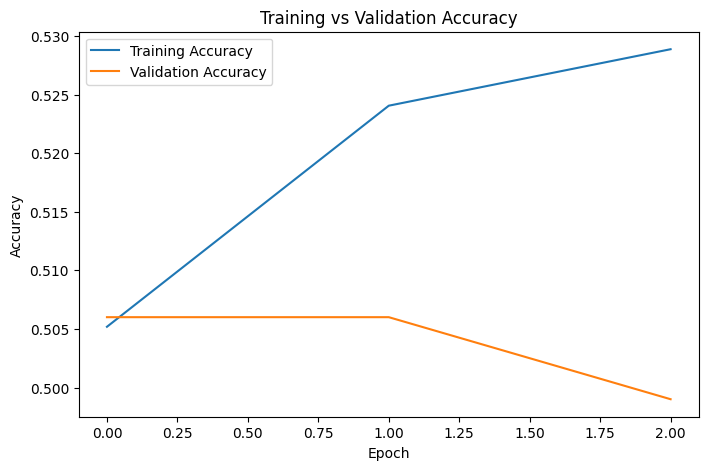

In [36]:
plt.figure(figsize=(8, 5))

plt.plot(train_accuracies, label="Training Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

In [37]:
model_5epoch = LSTMClassifier(
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    output_size=OUTPUT_SIZE
).to(device)

optimizer_5epoch = optim.Adam(model_5epoch.parameters(), lr=0.001)

EPOCHS = 5

train_losses_5, val_losses_5, train_accuracies_5, val_accuracies_5 = train_model(
    model=model_5epoch,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer_5epoch,
    criterion=criterion,
    epochs=EPOCHS
)

Epoch 1/5
Train Loss: 0.6935, Train Acc: 0.5036
Val Loss: 0.6919, Val Acc: 0.5117
----------------------------------------
Epoch 2/5
Train Loss: 0.6888, Train Acc: 0.5224
Val Loss: 0.6920, Val Acc: 0.5077
----------------------------------------
Epoch 3/5
Train Loss: 0.6743, Train Acc: 0.5257
Val Loss: 0.6976, Val Acc: 0.5053
----------------------------------------
Epoch 4/5
Train Loss: 0.6516, Train Acc: 0.5449
Val Loss: 0.7122, Val Acc: 0.5040
----------------------------------------
Epoch 5/5
Train Loss: 0.6344, Train Acc: 0.5473
Val Loss: 0.7402, Val Acc: 0.5017
----------------------------------------


In [38]:
def encode_and_pad_with_length(tokens, vocab, max_length):
    encoded = []

    for token in tokens:
        if token in vocab:
            encoded.append(vocab[token])
        else:
            encoded.append(vocab["<UNK>"])

    actual_length = min(len(encoded), max_length)

    if len(encoded) > max_length:
        encoded = encoded[:max_length]

    if len(encoded) < max_length:
        padding_needed = max_length - len(encoded)
        encoded = encoded + [vocab["<PAD>"]] * padding_needed

    return encoded, actual_length


X_train_with_lengths = [encode_and_pad_with_length(tokens, vocab, MAX_SEQUENCE_LENGTH) for tokens in processed_train_texts]
X_val_with_lengths = [encode_and_pad_with_length(tokens, vocab, MAX_SEQUENCE_LENGTH) for tokens in processed_val_texts]
X_test_with_lengths = [encode_and_pad_with_length(tokens, vocab, MAX_SEQUENCE_LENGTH) for tokens in processed_test_texts]

X_train = [item[0] for item in X_train_with_lengths]
train_lengths = [item[1] for item in X_train_with_lengths]

X_val = [item[0] for item in X_val_with_lengths]
val_lengths = [item[1] for item in X_val_with_lengths]

X_test = [item[0] for item in X_test_with_lengths]
test_lengths = [item[1] for item in X_test_with_lengths]

print("First encoded review length:", len(X_train[0]))
print("First actual review length:", train_lengths[0])
print("Minimum train length:", min(train_lengths))
print("Maximum train length:", max(train_lengths))

First encoded review length: 250
First actual review length: 63
Minimum train length: 4
Maximum train length: 250


In [39]:
class IMDBDataset(Dataset):
    def __init__(self, texts, labels, lengths):
        self.texts = torch.tensor(texts, dtype=torch.long)
        self.labels = torch.tensor(labels, dtype=torch.float32)
        self.lengths = torch.tensor(lengths, dtype=torch.long)

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, index):
        return self.texts[index], self.labels[index], self.lengths[index]


BATCH_SIZE = 64

train_dataset = IMDBDataset(X_train, y_train, train_lengths)
val_dataset = IMDBDataset(X_val, y_val, val_lengths)
test_dataset = IMDBDataset(X_test, y_test, test_lengths)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

sample_text_batch, sample_label_batch, sample_length_batch = next(iter(train_loader))

print("Sample text batch shape:", sample_text_batch.shape)
print("Sample label batch shape:", sample_label_batch.shape)
print("Sample length batch shape:", sample_length_batch.shape)

Sample text batch shape: torch.Size([64, 250])
Sample label batch shape: torch.Size([64])
Sample length batch shape: torch.Size([64])


In [48]:
from torch.nn.utils.rnn import pack_padded_sequence

class LSTMClassifierPacked(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_layers, output_size):
        super(LSTMClassifierPacked, self).__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x, lengths):
        # Convert word IDs into word vectors
        embedded = self.embedding(x)

        # Move lengths to CPU because pack_padded_sequence expects CPU lengths
        lengths = lengths.cpu()

        # Pack the padded sequence so the LSTM ignores padding tokens
        packed_embedded = pack_padded_sequence(
            embedded,
            lengths,
            batch_first=True,
            enforce_sorted=False
        )

        # Run the packed sequence through the LSTM
        packed_output, (hidden, cell) = self.lstm(packed_embedded)

        # Use the last hidden state from the final LSTM layer
        final_hidden = hidden[-1]

        # Convert final hidden state into one sentiment logit
        output = self.fc(final_hidden)

        return output.squeeze(1)

In [50]:
def train_model_packed(model, train_loader, val_loader, optimizer, criterion, epochs):
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    for epoch in range(epochs):
        model.train()

        total_train_loss = 0
        all_train_predictions = []
        all_train_labels = []

        for texts, labels, lengths in train_loader:
            texts = texts.to(device)
            labels = labels.to(device)
            lengths = lengths.to(device)

            optimizer.zero_grad()

            outputs = model(texts, lengths)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()

            probabilities = torch.sigmoid(outputs)
            predictions = (probabilities >= 0.5).float()

            all_train_predictions.extend(predictions.cpu().detach().numpy())
            all_train_labels.extend(labels.cpu().detach().numpy())

        avg_train_loss = total_train_loss / len(train_loader)
        train_accuracy = accuracy_score(all_train_labels, all_train_predictions)

        val_loss, val_accuracy = evaluate_model_packed(model, val_loader)

        train_losses.append(avg_train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_accuracy)
        val_accuracies.append(val_accuracy)

        print(f"Epoch {epoch + 1}/{epochs}")
        print(f"Train Loss: {avg_train_loss:.4f}, Train Acc: {train_accuracy:.4f}")
        print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.4f}")
        print("-" * 40)

    return train_losses, val_losses, train_accuracies, val_accuracies

In [51]:
def evaluate_model_packed(model, data_loader):
    model.eval()

    all_predictions = []
    all_labels = []
    total_loss = 0

    with torch.no_grad():
        for texts, labels, lengths in data_loader:
            texts = texts.to(device)
            labels = labels.to(device)
            lengths = lengths.to(device)

            outputs = model(texts, lengths)
            loss = criterion(outputs, labels)

            probabilities = torch.sigmoid(outputs)
            predictions = (probabilities >= 0.5).float()

            total_loss += loss.item()

            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(data_loader)
    accuracy = accuracy_score(all_labels, all_predictions)

    return avg_loss, accuracy

In [52]:
model_packed = LSTMClassifierPacked(
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    output_size=OUTPUT_SIZE
).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer_packed = optim.Adam(model_packed.parameters(), lr=0.001)

EPOCHS = 5

train_losses_packed, val_losses_packed, train_accuracies_packed, val_accuracies_packed = train_model_packed(
    model=model_packed,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer_packed,
    criterion=criterion,
    epochs=EPOCHS
)

Epoch 1/5
Train Loss: 0.6030, Train Acc: 0.6694
Val Loss: 0.6339, Val Acc: 0.6143
----------------------------------------
Epoch 2/5
Train Loss: 0.5838, Train Acc: 0.6850
Val Loss: 0.5941, Val Acc: 0.7070
----------------------------------------
Epoch 3/5
Train Loss: 0.4599, Train Acc: 0.7929
Val Loss: 0.4277, Val Acc: 0.8123
----------------------------------------
Epoch 4/5
Train Loss: 0.3753, Train Acc: 0.8381
Val Loss: 0.4028, Val Acc: 0.8173
----------------------------------------
Epoch 5/5
Train Loss: 0.3089, Train Acc: 0.8765
Val Loss: 0.3527, Val Acc: 0.8450
----------------------------------------


### Task 4 Training Analysis

The first simple LSTM model did not perform well and stayed close to random guessing on the validation set. This likely happened because each review was padded to a fixed length of 250 tokens, and the model treated padding tokens as part of the sequence. To improve this, I used a length-aware LSTM with `pack_padded_sequence`, which allows the model to ignore padded tokens and focus on the actual review content.

The improved LSTM showed much stronger learning. After 5 epochs, the training accuracy increased to 0.8765 and the validation accuracy reached 0.8450. This suggests that the model learned meaningful sentiment patterns from the text while still generalizing reasonably well to validation data.

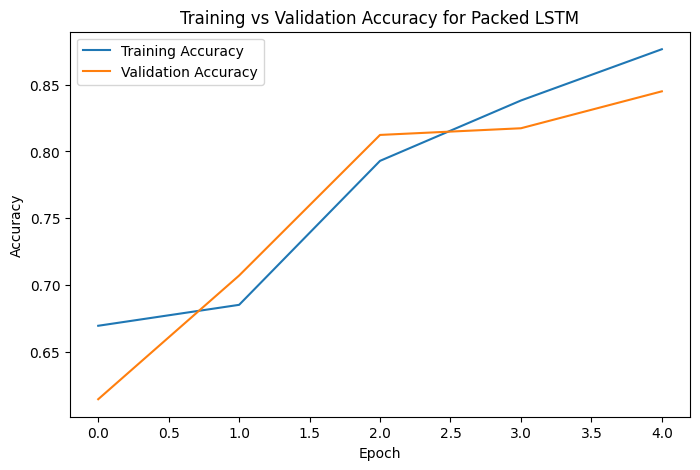

In [53]:
plt.figure(figsize=(8, 5))

plt.plot(train_accuracies_packed, label="Training Accuracy")
plt.plot(val_accuracies_packed, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy for Packed LSTM")
plt.legend()
plt.show()

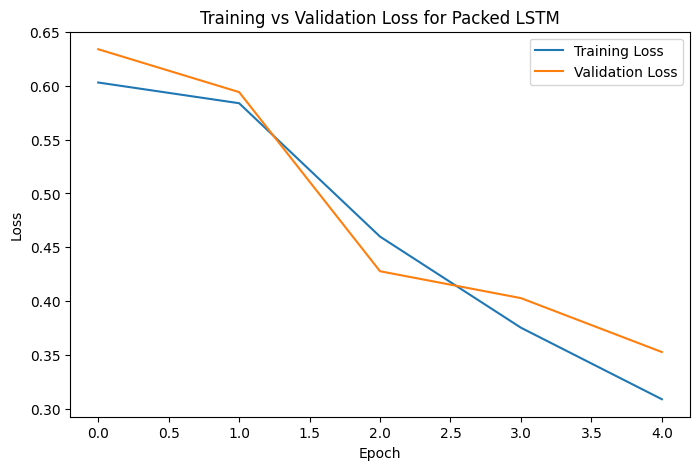

In [54]:
plt.figure(figsize=(8, 5))

plt.plot(train_losses_packed, label="Training Loss")
plt.plot(val_losses_packed, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss for Packed LSTM")
plt.legend()
plt.show()

### Plot Analysis

The accuracy plot shows that both training and validation accuracy increased across the 5 epochs. Training accuracy rose from about 0.67 to 0.88, while validation accuracy rose from about 0.61 to 0.85. This indicates that the packed LSTM learned useful sentiment patterns from the training data and also improved on unseen validation data.

The loss plot shows the same trend in the opposite direction. Training loss decreased from about 0.60 to 0.31, and validation loss decreased from about 0.63 to 0.35. Since validation loss also decreased, the model does not appear to be severely overfitting during these 5 epochs. The packed LSTM is a better design choice than the earlier simple LSTM because it uses the true sequence lengths and avoids treating padding tokens as meaningful words.

## Task 5: Performance Evaluation

In this section, I evaluate the final packed LSTM model on the test set. I report accuracy, precision, recall, F1 score, and AUC. These metrics give a broader picture of the classifier's performance than accuracy alone.

In [55]:
def evaluate_final_model(model, data_loader):
    model.eval()

    all_labels = []
    all_predictions = []
    all_probabilities = []

    with torch.no_grad():
        for texts, labels, lengths in data_loader:
            texts = texts.to(device)
            labels = labels.to(device)
            lengths = lengths.to(device)

            outputs = model(texts, lengths)

            probabilities = torch.sigmoid(outputs)
            predictions = (probabilities >= 0.5).float()

            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predictions.cpu().numpy())
            all_probabilities.extend(probabilities.cpu().numpy())

    accuracy = accuracy_score(all_labels, all_predictions)
    precision = precision_score(all_labels, all_predictions)
    recall = recall_score(all_labels, all_predictions)
    f1 = f1_score(all_labels, all_predictions)
    auc = roc_auc_score(all_labels, all_probabilities)

    return accuracy, precision, recall, f1, auc


test_accuracy, test_precision, test_recall, test_f1, test_auc = evaluate_final_model(
    model_packed,
    test_loader
)

print("Test Accuracy:", test_accuracy)
print("Test Precision:", test_precision)
print("Test Recall:", test_recall)
print("Test F1 Score:", test_f1)
print("Test AUC:", test_auc)

Test Accuracy: 0.83988
Test Precision: 0.818932512574131
Test Recall: 0.87272
Test F1 Score: 0.8449711475155881
Test AUC: 0.9169761856


### Task 5 Results and Analysis

The final packed LSTM model achieved a test accuracy of 0.8399, meaning it correctly classified about 84.0% of the IMDB test reviews. The precision was 0.8189, which means that when the model predicted a review was positive, it was correct about 81.9% of the time. The recall was 0.8727, meaning the model successfully found about 87.3% of the truly positive reviews.

The F1 score was 0.8450, which balances precision and recall into one metric. This is useful because it shows the model has a strong balance between avoiding false positives and avoiding false negatives. The AUC was 0.9170, which indicates that the model is very good at separating positive reviews from negative reviews across different classification thresholds.

Overall, these results suggest that the packed LSTM learned meaningful sentiment patterns from the IMDB review text and generalized well to the test set.

## Conclusion

In this project, I built a binary sentiment classifier for IMDB movie reviews using PyTorch and an LSTM-based neural network. I began by loading the IMDB train and test sets and computing review-length statistics. The average reviews were around 229–234 words, but some reviews were much longer, so I used a fixed sequence length of 250 tokens to balance information retention with training efficiency.

I then created a balanced validation set of 3000 reviews, with 1500 positive and 1500 negative samples. The remaining training set, validation set, and test set were all balanced, which made accuracy a meaningful evaluation metric. After that, I preprocessed the text by lowercasing, removing punctuation, removing stop words, tokenizing, and applying stemming.

For the model, I implemented an LSTM classifier with an embedding layer, an LSTM layer, and a fully connected output layer. A simple LSTM struggled because it treated padding tokens as part of the sequence. I improved the model by using a packed LSTM with true sequence lengths, allowing the network to ignore padding. This design choice produced much stronger validation performance, reaching 0.8450 validation accuracy after 5 epochs.

On the test set, the final model achieved 0.8399 accuracy, 0.8189 precision, 0.8727 recall, 0.8450 F1 score, and 0.9170 AUC. These results show that the model performed well overall and was especially strong at distinguishing positive and negative reviews.